In [1]:
import numpy as np
import torch
from torch import nn
from evolml.utils import PytorchModelEncoding, PytorchModelInitializer
from evolml.models import RBFLayer
import metaheuristic_designer as mhd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("white")

In [10]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.f1 = nn.Linear(1, 30)
        self.f2 = nn.Linear(30, 40)
        self.f3 = nn.Linear(40, 30)
        self.f4 = nn.Linear(30, 20)
        self.f5 = nn.Linear(20, 1)

        self.activ = nn.Sigmoid()
    
    def forward(self, x):
        x = self.activ(self.f1(x))
        x = self.activ(self.f2(x))
        x = self.activ(self.f3(x))
        x = self.activ(self.f4(x))

        return self.f5(x)

class EvalTorchModel(mhd.ObjectiveVectorFunc):
    def __init__(self, model_base, loss_fn, X, y, mode="min", name="Torch model evaluation"):
        n_params = sum(p.numel() for p in model_base.parameters() if p.requires_grad)
        super().__init__(vecsize=n_params, mode=mode, name=name)
        self.model_base = model_base
        self.loss_fn = loss_fn
        self.X = X
        self.y = y
    
    @torch.no_grad()
    def objective(self, model):
        pred = model(self.X)
        return self.loss_fn(pred, self.y).item()

    def repair_solution(self, solution):
        return solution     

X = torch.linspace(-2*torch.pi, 2*torch.pi, 10000).reshape((10000, 1))
y = torch.sinc(X)
# X = torch.linspace(-1, 1, 10000).reshape((10000, 1))
# y = 3*X**2 - X +1

model_base = MLP()
loss_fn = nn.MSELoss()

params = {
    # "stop_cond": "convergence or time_limit",
    "stop_cond": "time_limit",
    "progress_metric": "time_limit",
    "time_limit": 100.0,
    "cpu_time_limit": 100.0,
    "ngen": 1000,
    "neval": 3e6,
    "fit_target": 1e-10,
    "patience": 200,
    "verbose": True,
    "v_timer": 0.5,
}
objfunc = EvalTorchModel(model_base, loss_fn, X, y)
torch_encoding = PytorchModelEncoding(model_base)
# pop_init = mhd.initializers.UniformVectorInitializer(objfunc.vecsize, objfunc.low_lim, objfunc.up_lim, pop_size=100, encoding=torch_encoding)
# pop_init = PytorchModelInitializer(pop_size=1, encoding=torch_encoding)
pop_init = PytorchModelInitializer(model_base, pop_size=100, encoding=torch_encoding)
# pop_init = mhd.initializers.InitializerFromLambda(generator=generator, pop_size=1, encoding=torch_encoding)


search_strat = mhd.strategies.PSO(pop_init, params={"w": 0.8, "c1": 1.5, "c2": 1.5})
# search_strat = mhd.strategies.RandomSearch(pop_init)
# search_strat = mhd.strategies.HillClimb(pop_init, mhd.operators.OperatorReal("RandNoise", {"distrib": "gauss", "F": 1e-1, "N": 100}))
# search_strat = mhd.strategies.SA(pop_init, mhd.operators.OperatorReal("RandNoise", {"distrib": "gauss", "F": 1e-2, "N": 50}), params={"iter": 100, "temp_init": 1, "alpha": 0.997})
# search_strat = mhd.strategies.DE(pop_init, mhd.operators.OperatorReal("DE/best/1", {"F": 0.8, "Cr": 0.8}))
# search_strat = mhd.strategies.DE(pop_init, mhd.operators.OperatorReal("DE/current-to-best/1", {"F": 0.8, "Cr": 0.8}))
# search_strat = mhd.strategies.GA(
#     pop_init,
#     mhd.operators.OperatorReal("MutNoise", {"distrib": "gauss", "F": 1e-2, "N": 50}),
#     mhd.operators.OperatorReal("Multipoint"),
#     mhd.selectionMethods.ParentSelectionNull(),
#     # mhd.selectionMethods.SurvivorSelection("(m+n)")
#     mhd.selectionMethods.SurvivorSelection("Elitism", {"amount": 10})
# )
algorithm = mhd.GeneralAlgorithm(objfunc, search_strat, params=params)

In [11]:
ind, fit = algorithm.optimize()

Initializing optimization of Torch model evaluation using PSO
-------------------------------------------------------------

Optimizing Torch model evaluation using PSO:
	Real time Spent: 0.28 s
	CPU time Spent:  0.28 s
	Generation: 0
	Best fitness: 0.07218823581933975
	Evaluations of fitness: 100

	diversity: 0.127
	mean speed: 0.499

Optimizing Torch model evaluation using PSO:
	Real time Spent: 0.51 s
	CPU time Spent:  0.51 s
	Generation: 1
	Best fitness: 0.07218823581933975
	Evaluations of fitness: 200

	diversity: 0.265
	mean speed: 0.401

Optimizing Torch model evaluation using PSO:
	Real time Spent: 1.19 s
	CPU time Spent:  1.19 s
	Generation: 4
	Best fitness: 0.07216597348451614
	Evaluations of fitness: 500

	diversity: 0.374
	mean speed: -0.331

Optimizing Torch model evaluation using PSO:
	Real time Spent: 1.87 s
	CPU time Spent:  1.87 s
	Generation: 7
	Best fitness: 0.06901391595602036
	Evaluations of fitness: 800

	diversity: 0.792
	mean speed: -0.00699

Optimizing Torch mo

torch.Size([10000, 1])


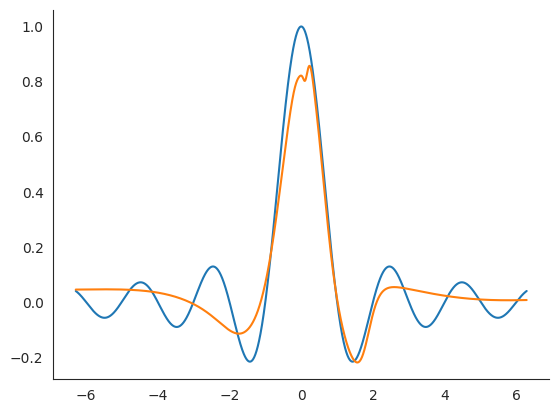

In [12]:
best_model = torch_encoding.decode(ind)
pred = best_model(X).detach()
print(pred.shape)

plt.plot(X, y)
plt.plot(X, pred)
sns.despine()